In [45]:
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import (
    Dense, Reshape, Conv2D, Conv2DTranspose,
    LeakyReLU, BatchNormalization, Flatten
)
import matplotlib.pyplot as plt
import numpy as np

In [33]:
(X_train, _), (_, _) = tf.keras.datasets.mnist.load_data()


In [34]:
X_train = X_train[:10000]


In [35]:
X_train = X_train.astype("float32")
X_train = (X_train - 127.5) / 127.5

# Add channel dimension
# (10000, 28, 28) -> (10000, 28, 28, 1)
X_train = np.expand_dims(X_train, axis=-1)

In [36]:
generator = Sequential([
    Input(shape=(100,)),

    Dense(7 * 7 * 128),
    BatchNormalization(),
    LeakyReLU(negative_slope=0.2),

    Reshape((7, 7, 128)),

    Conv2DTranspose(
        64,
        kernel_size=(4, 4),
        strides=(2, 2),
        padding="same"
    ),
    BatchNormalization(),
    LeakyReLU(negative_slope=0.2),

    Conv2DTranspose(
        32,
        kernel_size=(4, 4),
        strides=(2, 2),
        padding="same"
    ),
     BatchNormalization(),
    LeakyReLU(negative_slope=0.2),

    Conv2D(
        1,
        kernel_size=(3, 3),
        padding="same",
        activation="tanh"
    )
])


In [37]:
discriminator = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(
        64,
        kernel_size=(3, 3),
        strides=(2, 2),
        padding="same"
    ),
    LeakyReLU(negative_slope=0.2),

    Conv2D(
        128,
        kernel_size=(3, 3),
        strides=(2, 2),
        padding="same"
    ),
    LeakyReLU(negative_slope=0.2),

    Flatten(),

    Dense(1, activation="sigmoid")
])

In [38]:
discriminator.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0002,
        beta_1=0.5
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [39]:
discriminator.trainable = False

gan = Sequential([
    Input(shape=(100,)),
    generator,
    discriminator
])

gan.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0002,
        beta_1=0.5
    ),
    loss="binary_crossentropy"
)



In [40]:
epochs = 30
batch_size = 64
steps_per_epoch = len(X_train) // batch_size



In [41]:
for epoch in range(epochs):

    d_losses = []
    g_losses = []

    for step in range(steps_per_epoch):

        # -------------------------
        # Select real images
        # -------------------------

        idx = np.random.randint(
            0,
            X_train.shape[0],
            batch_size
        )

        real_images = X_train[idx]


In [42]:
noise = np.random.normal(0, 1, (batch_size, 100))

fake_images = generator.predict(
    noise,
    verbose=0
)


In [43]:
real_labels = np.ones((batch_size, 1))

fake_labels = np.zeros((batch_size, 1))

In [44]:
        discriminator.trainable = True

        d_loss_real = discriminator.train_on_batch(real_images, real_labels)
        d_loss_fake = discriminator.train_on_batch(fake_images, fake_labels)

        d_loss = (d_loss_real[0] + d_loss_fake[0]) / 2

        d_losses.append(d_loss)


In [29]:
# -----------------------------
# Training
# -----------------------------

epochs = 30
batch_size = 64
steps_per_epoch = len(X_train) // batch_size

for epoch in range(epochs):

    d_losses = []
    g_losses = []

    for step in range(steps_per_epoch):

        # Select real images
        idx = np.random.randint(
            0,
            X_train.shape[0],
            batch_size
        )

        real_images = X_train[idx]

        # Generate fake images
        noise = np.random.normal(
            0,
            1,
            (batch_size, 100)
        )

        fake_images = generator.predict(
            noise,
            verbose=0
        )

        # Labels
        real_labels = np.ones((batch_size, 1))
        fake_labels = np.zeros((batch_size, 1))

        # Train Discriminator
        discriminator.trainable = True

        d_loss_real = discriminator.train_on_batch(
            real_images,
            real_labels
        )

        d_loss_fake = discriminator.train_on_batch(
            fake_images,
            fake_labels
        )

        d_loss = (d_loss_real[0] + d_loss_fake[0]) / 2

        d_losses.append(d_loss)

        # Train Generator
        discriminator.trainable = False

        noise = np.random.normal(
            0,
            1,
            (batch_size, 100)
        )

        misleading_labels = np.ones((batch_size, 1))

        g_loss = gan.train_on_batch(
            noise,
            misleading_labels
        )

        g_losses.append(float(g_loss))

    # Print average loss after each epoch
    print(
        f"Epoch: {epoch + 1}/{epochs} "
        f"D Loss: {np.mean(d_losses):.4f} "
        f"G Loss: {np.mean(g_losses):.4f}"
    )

Epoch: 1/30 D Loss: 0.3389 G Loss: 0.2890
Epoch: 2/30 D Loss: 0.1452 G Loss: 0.1405
Epoch: 3/30 D Loss: 0.2102 G Loss: 0.7567
Epoch: 4/30 D Loss: 0.2798 G Loss: 0.6749
Epoch: 5/30 D Loss: 0.3722 G Loss: 0.6122
Epoch: 6/30 D Loss: 0.4427 G Loss: 0.6314
Epoch: 7/30 D Loss: 0.4886 G Loss: 0.6519
Epoch: 8/30 D Loss: 0.5221 G Loss: 0.6663
Epoch: 9/30 D Loss: 0.5452 G Loss: 0.6776
Epoch: 10/30 D Loss: 0.5616 G Loss: 0.6874
Epoch: 11/30 D Loss: 0.5730 G Loss: 0.6971
Epoch: 12/30 D Loss: 0.5814 G Loss: 0.7064
Epoch: 13/30 D Loss: 0.5879 G Loss: 0.7146
Epoch: 14/30 D Loss: 0.5926 G Loss: 0.7226
Epoch: 15/30 D Loss: 0.5967 G Loss: 0.7298
Epoch: 16/30 D Loss: 0.6005 G Loss: 0.7358
Epoch: 17/30 D Loss: 0.6043 G Loss: 0.7402
Epoch: 18/30 D Loss: 0.6082 G Loss: 0.7433
Epoch: 19/30 D Loss: 0.6122 G Loss: 0.7452
Epoch: 20/30 D Loss: 0.6162 G Loss: 0.7468
Epoch: 21/30 D Loss: 0.6199 G Loss: 0.7479
Epoch: 22/30 D Loss: 0.6234 G Loss: 0.7486
Epoch: 23/30 D Loss: 0.6267 G Loss: 0.7489
Epoch: 24/30 D Loss:

In [30]:
# Generate 10 random images
noise = np.random.normal(
    0,
    1,
    (10, 100)
)

generated_images = generator.predict(
    noise,
    verbose=0
)

# Convert images from [-1, 1] to [0, 1]
generated_images = (
    generated_images + 1
) / 2

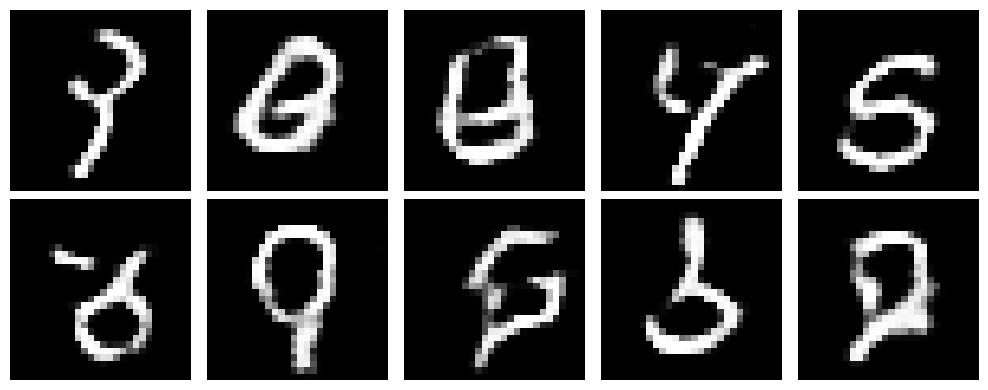

In [31]:
plt.figure(figsize=(10, 4))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        generated_images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()